## Imports

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import gaussian_filter, rotate, shift
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
from skimage.transform import resize

## Configuration

In [2]:
VAL_SUBJECT = "TV4_20220204_sorted_UCL"
TEST_SUBJECT = "TV8_20220307_sorted_UCL"

CROP_SIZE = 80
SCALE_FACTOR = 1.5
FWHM_PX = SCALE_FACTOR
SIGMA_REF = FWHM_PX / (2 * np.sqrt(2 * np.log(2)))
SIGMA_MIN = SIGMA_REF * 0.7
SIGMA_MAX = SIGMA_REF * 1.3

CHANNELS = [8, 16, 32, 64]
EPOCHS = 40
TARGET_FRAMES_PER_SERIES = 30
USE_PHASE_BALANCED_SAMPLING = False

USE_GEOMETRIC_AUG = True
AUG_MAX_ROTATION_DEG = 5.0
AUG_MAX_TRANSLATION_PX = 3.0

BATCH_SIZE = 32
LEARNING_RATE = 1e-3
SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 0
MAX_EPOCH_MINUTES = 15

candidate_output_dirs = [Path.cwd(), Path.cwd() / "Development"]
OUTPUT_DIR = next((d / "Outputs" for d in candidate_output_dirs if (d / "Outputs").exists()), Path.cwd() / "Outputs")
EXPORT_PATH = OUTPUT_DIR / "tv_hr_crop_synthetic_lr_export.npz"
assert EXPORT_PATH.exists(), f"Export file not found at {EXPORT_PATH.resolve()}"

CHECKPOINT_PATH = OUTPUT_DIR / "spatial_baseline_best.pt"
HISTORY_PATH = OUTPUT_DIR / "spatial_baseline_history.csv"
HISTMATCH_CHECKPOINT_PATH = OUTPUT_DIR / "spatial_baseline_histmatch_best.pt"
HISTMATCH_HISTORY_PATH = OUTPUT_DIR / "spatial_baseline_histmatch_history.csv"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

In [3]:
print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))
    print("cuda version:", torch.version.cuda)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"total vram: {vram_gb:.1f} gb")
else:
    print("no gpu available, running on cpu")

device: cuda
gpu name: NVIDIA GeForce RTX 5060 Laptop GPU
cuda version: 13.2
total vram: 8.5 gb


## Data Preparation

In [4]:
export_data = np.load(EXPORT_PATH, allow_pickle=True)
print("export arrays:", list(export_data.files))

hr_frames = export_data["hr_frames"]
included = export_data["included"]
subject = export_data["subject"]
sl = export_data["slice"]
dyn = export_data["dynamic"]
phase_bin = export_data["phase_bin"]

print("total exported frames:", len(hr_frames))
print("frame shape:", hr_frames.shape[1:])

hr_frames = hr_frames[included]
subject = subject[included]
sl = sl[included]
dyn = dyn[included]
phase_bin = phase_bin[included]

print("included frame count after filtering:", len(hr_frames))

export arrays: ['hr_frames', 'lr_synth_frames', 'subject', 'slice', 'dynamic', 'phase_bin', 'phase_direction', 'anchor_row', 'anchor_col', 'crop_origin_row', 'crop_origin_col', 'included']
total exported frames: 9120
frame shape: (80, 80)
included frame count after filtering: 7030


In [5]:
assert "echo" not in export_data.files
echoes_used = ["TE1"]
print("echo(es) used:", echoes_used)

echo(es) used: ['TE1']


In [6]:
all_subjects = sorted(set(subject.tolist()))
train_subjects = [s for s in all_subjects if s not in (VAL_SUBJECT, TEST_SUBJECT)]

# Split by subject to avoid temporal leakage.
train_mask = np.isin(subject, train_subjects)
val_mask = subject == VAL_SUBJECT
test_mask = subject == TEST_SUBJECT

train_idx = np.where(train_mask)[0]
val_idx = np.where(val_mask)[0]
test_idx = np.where(test_mask)[0]

print("train subjects:", train_subjects)
print("val subject:", VAL_SUBJECT)
print("test subject:", TEST_SUBJECT)
print("train/val/test frame counts:", len(train_idx), len(val_idx), len(test_idx))

for s in all_subjects:
    group = "val" if s == VAL_SUBJECT else "test" if s == TEST_SUBJECT else "train"
    print(f"  {s} ({group}): {int((subject == s).sum())}")


train subjects: ['TV1_20220222_sorted_UCL', 'TV2_20220222_sorted_UCL', 'TV3_20220208_sorted_UCL', 'TV5_20220307_sorted_UCL', 'TV6_20220307_sorted_UCL', 'TV7_20220315_sorted_UCL']
val subject: TV4_20220204_sorted_UCL
test subject: TV8_20220307_sorted_UCL
train/val/test frame counts: 4750 1140 1140
  TV1_20220222_sorted_UCL (train): 1140
  TV2_20220222_sorted_UCL (train): 760
  TV3_20220208_sorted_UCL (train): 950
  TV4_20220204_sorted_UCL (val): 1140
  TV5_20220307_sorted_UCL (train): 760
  TV6_20220307_sorted_UCL (train): 570
  TV7_20220315_sorted_UCL (train): 570
  TV8_20220307_sorted_UCL (test): 1140


In [7]:
def degrade_hr_to_lr(image, blur_sigma=SIGMA_REF, downsample_factor=SCALE_FACTOR):
    blur_mode = "constant"
    blurred = gaussian_filter(image.astype(np.float64), sigma=blur_sigma, mode=blur_mode, cval=0.0)
    support = gaussian_filter(np.ones_like(image, dtype=np.float64), sigma=blur_sigma, mode=blur_mode, cval=0.0)
    blurred = blurred / np.maximum(support, 1e-3)

    size = image.shape[0]
    small_size = max(1, int(round(size / downsample_factor)))
    downsampled = resize(blurred, (small_size, small_size), order=3, mode="edge", anti_aliasing=False, preserve_range=True)
    return resize(downsampled, (size, size), order=3, mode="edge", anti_aliasing=False, preserve_range=True)


def compute_percentile_scale(frames, subject, sl, low=1, high=99):
    scale = {}
    for key in set(zip(subject.tolist(), sl.tolist())):
        series = frames[(subject == key[0]) & (sl == key[1])]
        scale[key] = tuple(np.percentile(series, [low, high]))
    return scale


def normalise(img, lo, hi):
    return np.clip((img - lo) / max(hi - lo, 1e-6), 0.0, 1.0)


def denormalise(img, lo, hi):
    return img * (hi - lo) + lo


# Scale both LR and HR using fixed-reference LR statistics.
lr_frames_ref = np.stack([degrade_hr_to_lr(f, blur_sigma=SIGMA_REF) for f in hr_frames])
percentile_scale = compute_percentile_scale(lr_frames_ref, subject, sl)
print(f"percentile scaling computed for {len(percentile_scale)} subject/slice series")

percentile scaling computed for 37 subject/slice series


## Augmentation and Histogram Matching

In [8]:
def augment_hr_geometric(image):
    angle = np.random.uniform(-AUG_MAX_ROTATION_DEG, AUG_MAX_ROTATION_DEG)
    dx = np.random.uniform(-AUG_MAX_TRANSLATION_PX, AUG_MAX_TRANSLATION_PX)
    dy = np.random.uniform(-AUG_MAX_TRANSLATION_PX, AUG_MAX_TRANSLATION_PX)
    rotated = rotate(image, angle, reshape=False, order=3, mode="nearest")
    return shift(rotated, shift=(dy, dx), order=3, mode="nearest")


def augment_hr_geometric_with_mask(image, mask):
    angle = np.random.uniform(-AUG_MAX_ROTATION_DEG, AUG_MAX_ROTATION_DEG)
    dx = np.random.uniform(-AUG_MAX_TRANSLATION_PX, AUG_MAX_TRANSLATION_PX)
    dy = np.random.uniform(-AUG_MAX_TRANSLATION_PX, AUG_MAX_TRANSLATION_PX)

    rotated_image = rotate(image, angle, reshape=False, order=3, mode="nearest")
    shifted_image = shift(rotated_image, shift=(dy, dx), order=3, mode="nearest")
    rotated_mask = rotate(mask.astype(np.float32), angle, reshape=False, order=0, mode="nearest")
    shifted_mask = shift(rotated_mask, shift=(dy, dx), order=0, mode="nearest")
    return shifted_image, shifted_mask > 0.5

In [25]:
REAL_PAIRS_PATH = OUTPUT_DIR / "iqt_real_pairs_export.npz"
_body_mask_path = OUTPUT_DIR / "tv_hr_crop_body_mask_export.npz"
assert REAL_PAIRS_PATH.exists(), f"Real IQT pairs not found at {REAL_PAIRS_PATH.resolve()}"
assert _body_mask_path.exists(), f"Body-mask export not found at {_body_mask_path.resolve()}"

real_data = np.load(REAL_PAIRS_PATH, allow_pickle=True)
real_included = real_data["included"].astype(bool) if "included" in real_data.files else np.ones(len(real_data["lr_frames"]), dtype=bool)
real_lr_frames = real_data["lr_frames"][real_included]
real_slices = real_data["slice"][real_included]

real_lr_normalised = []
for slice_id in np.unique(real_slices):
    slice_frames = real_lr_frames[real_slices == slice_id]
    lo, hi = np.percentile(slice_frames, [1, 99])
    real_lr_normalised.extend(normalise(frame, lo, hi) for frame in slice_frames)

real_lr_normalised = np.asarray(real_lr_normalised)
real_reference_pixels = real_lr_normalised[real_lr_normalised > 0.02]
real_reference_values, real_reference_counts = np.unique(real_reference_pixels, return_counts=True)
real_reference_cdf = np.cumsum(real_reference_counts).astype(np.float64)
real_reference_cdf /= real_reference_cdf[-1]

_body_mask_data = np.load(_body_mask_path, allow_pickle=True)
tv_body_mask_full = _body_mask_data["body_mask"]
tv_body_seg_success_full = _body_mask_data["seg_success"]

assert tv_body_mask_full.shape[0] == len(hr_frames), "Body-mask row count does not match hr_frames"
assert np.array_equal(_body_mask_data["subject"], subject), "Body-mask subject identifiers are misaligned"
assert np.array_equal(_body_mask_data["slice"], sl), "Body-mask slice identifiers are misaligned"
assert np.array_equal(_body_mask_data["dynamic"], dyn), "Body-mask dynamic identifiers are misaligned"

tv_body_mask_full = tv_body_mask_full & tv_body_seg_success_full[:, None, None]
print(f"real LR reference frames: {len(real_lr_normalised)}")
print(f"real reference pixels: {len(real_reference_pixels)}")
print(f"usable body masks: {int(tv_body_mask_full.any(axis=(1, 2)).sum())}/{len(tv_body_mask_full)}")


def histogram_match(image, mask):
    matched = image.copy()
    source_pixels = image[mask]

    if len(source_pixels) == 0:
        return matched

    source_values, source_counts = np.unique(source_pixels, return_counts=True)
    source_cdf = np.cumsum(source_counts).astype(np.float64)
    source_cdf /= source_cdf[-1]

    mapped_values = np.interp(source_cdf, real_reference_cdf, real_reference_values)
    matched[mask] = np.interp(source_pixels, source_values, mapped_values)
    return np.clip(matched, 0.0, 1.0)


real LR reference frames: 180
real reference pixels: 1093560
usable body masks: 6969/7030


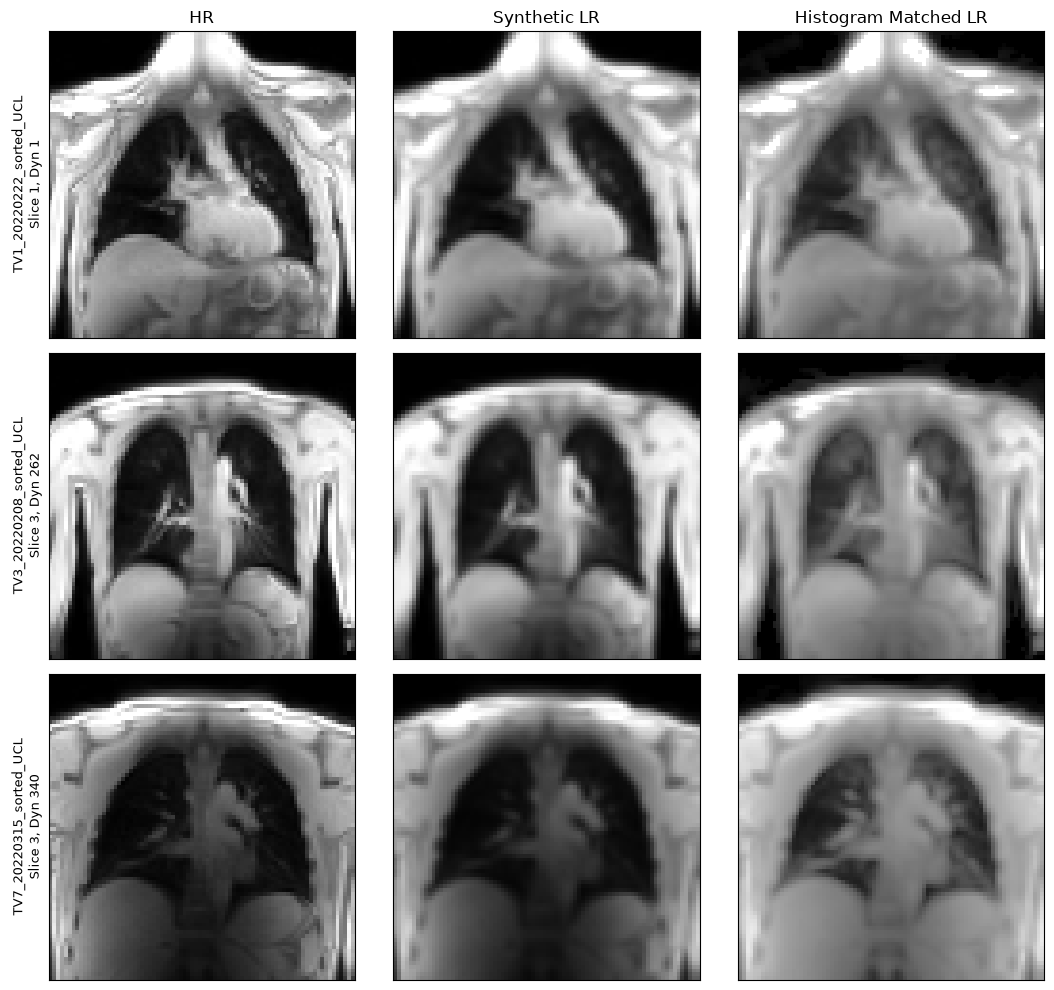

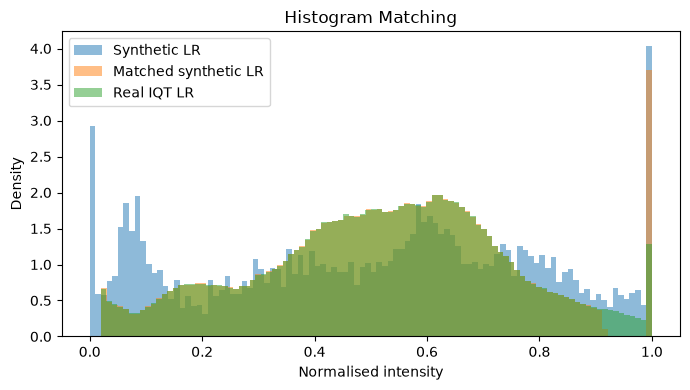

synthetic LR mean: 0.5028
matched LR mean: 0.5215
real IQT LR mean: 0.5202


In [27]:
masked_train_idx = train_idx[tv_body_mask_full[train_idx].any(axis=(1, 2))]
frame_indices = masked_train_idx[np.linspace(0, len(masked_train_idx) - 1, 3, dtype=int)]

fig, axes = plt.subplots(3, 3, figsize=(11, 10))

for row, idx in enumerate(frame_indices):
    hr = hr_frames[idx]
    mask = tv_body_mask_full[idx]
    lo, hi = percentile_scale[(subject[idx], sl[idx])]

    lr = degrade_hr_to_lr(hr, blur_sigma=SIGMA_REF)
    hr_n = normalise(hr, lo, hi)
    lr_n = normalise(lr, lo, hi)
    matched = histogram_match(lr_n, mask)

    images = [hr_n, lr_n, matched]
    titles = ["HR", "Synthetic LR", "Histogram Matched LR"]

    for col, (image, title) in enumerate(zip(images, titles)):
        axes[row, col].imshow(image, cmap="gray", vmin=0, vmax=1)

        if row == 0:
            axes[row, col].set_title(title)
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

    axes[row, 0].set_ylabel(f"{subject[idx]}\nSlice {sl[idx]}, Dyn {dyn[idx]}", fontsize=9)

plt.tight_layout()
plt.show()

idx = frame_indices[0]
hr = hr_frames[idx]
mask = tv_body_mask_full[idx]
lo, hi = percentile_scale[(subject[idx], sl[idx])]
lr_n = normalise(degrade_hr_to_lr(hr, blur_sigma=SIGMA_REF), lo, hi)
matched = histogram_match(lr_n, mask)

plt.figure(figsize=(7, 4))
plt.hist(lr_n[mask], bins=100, density=True, alpha=0.5, label="Synthetic LR")
plt.hist(matched[mask], bins=100, density=True, alpha=0.5, label="Matched synthetic LR")
plt.hist(real_reference_pixels, bins=100, density=True, alpha=0.5, label="Real IQT LR")
plt.xlabel("Normalised intensity")
plt.ylabel("Density")
plt.title("Histogram Matching")
plt.legend()
plt.tight_layout()
plt.show()

print(f"synthetic LR mean: {lr_n[mask].mean():.4f}")
print(f"matched LR mean: {matched[mask].mean():.4f}")
print(f"real IQT LR mean: {real_reference_pixels.mean():.4f}")


## Datasets and Sampling

In [10]:
class SpatialPairDataset(torch.utils.data.Dataset):
    def __init__(self, indices, sigma_min, sigma_max, fixed_sigma=None, augment=False):
        self.indices = indices
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
        self.fixed_sigma = fixed_sigma
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        hr = hr_frames[idx]
        lo, hi = percentile_scale[(subject[idx], sl[idx])]

        if self.augment:
            hr = augment_hr_geometric(hr)

        sigma = self.fixed_sigma if self.fixed_sigma is not None else np.random.uniform(self.sigma_min, self.sigma_max)
        lr = degrade_hr_to_lr(hr, blur_sigma=sigma)

        hr_t = torch.from_numpy(normalise(hr, lo, hi)).float().unsqueeze(0)
        lr_t = torch.from_numpy(normalise(lr, lo, hi)).float().unsqueeze(0)
        return lr_t, hr_t


class HistMatchSpatialPairDataset(torch.utils.data.Dataset):
    def __init__(self, indices, sigma_min, sigma_max, body_mask, fixed_sigma=None, augment=False):
        self.indices = indices
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
        self.fixed_sigma = fixed_sigma
        self.augment = augment
        self.body_mask = body_mask

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        hr = hr_frames[idx]
        mask = self.body_mask[idx]
        lo, hi = percentile_scale[(subject[idx], sl[idx])]

        if self.augment:
            hr, mask = augment_hr_geometric_with_mask(hr, mask)

        sigma = self.fixed_sigma if self.fixed_sigma is not None else np.random.uniform(self.sigma_min, self.sigma_max)
        lr = degrade_hr_to_lr(hr, blur_sigma=sigma)
        hr_t = normalise(hr, lo, hi)
        lr_t = normalise(lr, lo, hi)

        if mask.any():
            lr_t = lr_t.copy()
            lr_t[mask] = apply_histogram_mapping(lr_t[mask])

        hr_t = torch.from_numpy(hr_t).float().unsqueeze(0)
        lr_t = torch.from_numpy(lr_t).float().unsqueeze(0)
        return lr_t, hr_t

In [11]:
def sample_series_positions(positions, phase_values, target_n, rng):
    n = min(target_n, len(positions))
    valid = ~np.isnan(phase_values)
    if valid.sum() < 2:
        return rng.choice(positions, size=n, replace=False)

    bins = {b: positions[valid][phase_values[valid] == b] for b in np.unique(phase_values[valid])}
    if (~valid).any():
        bins["unknown"] = positions[~valid]

    quotas = {k: 0 for k in bins}
    active = set(bins)
    remaining = n

    while remaining > 0 and active:
        share = max(1, remaining // len(active))
        for key in list(active):
            take = min(share, len(bins[key]) - quotas[key], remaining)
            quotas[key] += take
            remaining -= take
            if quotas[key] >= len(bins[key]):
                active.discard(key)
            if remaining == 0:
                break

    chosen = [rng.choice(bins[k], size=quotas[k], replace=False) for k in bins if quotas[k] > 0]
    return np.concatenate(chosen)


class PhaseBalancedEpochSampler(torch.utils.data.Sampler):
    def __init__(self, local_subject, local_sl, local_phase, target_per_series, seed):
        self.local_subject = local_subject
        self.local_sl = local_sl
        self.local_phase = local_phase
        self.target_per_series = target_per_series
        self.rng = np.random.default_rng(seed)
        self.series_keys = sorted(set(zip(local_subject.tolist(), local_sl.tolist())))
        self.series_sizes = {
            key: int(((local_subject == key[0]) & (local_sl == key[1])).sum())
            for key in self.series_keys
        }
        self.last_counts = {}

    def __iter__(self):
        chosen_per_series = []
        for key in self.series_keys:
            mask = (self.local_subject == key[0]) & (self.local_sl == key[1])
            positions = np.where(mask)[0]
            phases = self.local_phase[positions]
            chosen = sample_series_positions(positions, phases, self.target_per_series, self.rng)
            chosen_per_series.append(chosen)
            self.last_counts[key] = len(chosen)

        all_positions = np.concatenate(chosen_per_series)
        self.rng.shuffle(all_positions)
        return iter(all_positions.tolist())

    def __len__(self):
        return sum(min(self.target_per_series, n) for n in self.series_sizes.values())

In [12]:
pin_memory = DEVICE == "cuda"

train_ds = SpatialPairDataset(train_idx, SIGMA_MIN, SIGMA_MAX, augment=USE_GEOMETRIC_AUG)
val_ds = SpatialPairDataset(val_idx, SIGMA_MIN, SIGMA_MAX, fixed_sigma=SIGMA_REF)

train_ds_histmatch = HistMatchSpatialPairDataset(train_idx, SIGMA_MIN, SIGMA_MAX, tv_body_mask_full, augment=USE_GEOMETRIC_AUG)
val_ds_histmatch = HistMatchSpatialPairDataset(val_idx, SIGMA_MIN, SIGMA_MAX, tv_body_mask_full, fixed_sigma=SIGMA_REF)

train_sampler = PhaseBalancedEpochSampler(subject[train_idx], sl[train_idx], phase_bin[train_idx], TARGET_FRAMES_PER_SERIES, SEED)
histmatch_train_sampler = PhaseBalancedEpochSampler(subject[train_idx], sl[train_idx], phase_bin[train_idx], TARGET_FRAMES_PER_SERIES, SEED)

if USE_PHASE_BALANCED_SAMPLING:
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=pin_memory)
    train_loader_histmatch = torch.utils.data.DataLoader(train_ds_histmatch, batch_size=BATCH_SIZE, sampler=histmatch_train_sampler, num_workers=NUM_WORKERS, pin_memory=pin_memory)
else:
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)
    train_loader_histmatch = torch.utils.data.DataLoader(train_ds_histmatch, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory)

val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
val_loader_histmatch = torch.utils.data.DataLoader(val_ds_histmatch, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

sampling_mode = "phase-balanced" if USE_PHASE_BALANCED_SAMPLING else "full-frame shuffle"
print("training sampling:", sampling_mode)
print("available training frames:", len(train_idx))
if USE_PHASE_BALANCED_SAMPLING:
    print("phase-balanced frames per epoch:", len(train_sampler))


training sampling: full-frame shuffle
available training frames: 4750


## Model

In [13]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, channels):
        super().__init__()
        c1, c2, c3, c4 = channels
        self.pool = nn.MaxPool2d(2)

        self.enc1 = ConvBlock(1, c1)
        self.enc2 = ConvBlock(c1, c2)
        self.enc3 = ConvBlock(c2, c3)
        self.enc4 = ConvBlock(c3, c4)
        self.bottleneck = ConvBlock(c4, c4)

        self.up4 = nn.ConvTranspose2d(c4, c4, 2, stride=2)
        self.dec4 = ConvBlock(c4 + c4, c3)
        self.up3 = nn.ConvTranspose2d(c3, c3, 2, stride=2)
        self.dec3 = ConvBlock(c3 + c3, c2)
        self.up2 = nn.ConvTranspose2d(c2, c2, 2, stride=2)
        self.dec2 = ConvBlock(c2 + c2, c1)
        self.up1 = nn.ConvTranspose2d(c1, c1, 2, stride=2)
        self.dec1 = ConvBlock(c1 + c1, c1)
        self.out_conv = nn.Conv2d(c1, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


torch.manual_seed(SEED)
model = UNet(CHANNELS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("channels:", CHANNELS)
print("trainable parameters:", n_params)

channels: [8, 16, 32, 64]
trainable parameters: 232537


## Training Loop

In [14]:
def psnr_batch(pred, target):
    pred_np = pred.detach().cpu().numpy()
    target_np = target.detach().cpu().numpy()
    scores = [peak_signal_noise_ratio(target_np[i, 0], pred_np[i, 0], data_range=1.0) for i in range(pred_np.shape[0])]
    return float(np.mean(scores))


def ssim_batch(pred, target):
    pred_np = pred.detach().cpu().numpy()
    target_np = target.detach().cpu().numpy()
    scores = [structural_similarity(target_np[i, 0], pred_np[i, 0], data_range=1.0) for i in range(pred_np.shape[0])]
    return float(np.mean(scores))


def run_train_epoch(model, loader, optimizer):
    model.train()
    total_loss, n = 0.0, 0

    for lr, hr in loader:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        pred_residual = model(lr)
        loss = F.l1_loss(pred_residual, hr - lr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * lr.size(0)
        n += lr.size(0)

    return total_loss / n


def validate(model, loader):
    model.eval()
    total = {"loss": 0.0, "psnr": 0.0, "ssim": 0.0, "baseline_psnr": 0.0, "baseline_ssim": 0.0}
    n = 0

    with torch.no_grad():
        for lr, hr in loader:
            lr, hr = lr.to(DEVICE), hr.to(DEVICE)
            pred_residual = model(lr)
            loss = F.l1_loss(pred_residual, hr - lr)
            prediction = (lr + pred_residual).clamp(0.0, 1.0)

            bs = lr.size(0)
            total["loss"] += loss.item() * bs
            total["psnr"] += psnr_batch(prediction, hr) * bs
            total["ssim"] += ssim_batch(prediction, hr) * bs
            total["baseline_psnr"] += psnr_batch(lr, hr) * bs
            total["baseline_ssim"] += ssim_batch(lr, hr) * bs
            n += bs

    return {k: v / n for k, v in total.items()}


def train_model(model, train_loader, val_loader, epochs, learning_rate, checkpoint_path, history_path):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    best_val_psnr = -float("inf")
    history = []

    for epoch in range(epochs):
        epoch_start = time.time()
        train_loss = run_train_epoch(model, train_loader, optimizer)
        val_metrics = validate(model, val_loader)
        epoch_minutes = (time.time() - epoch_start) / 60

        print(
            f"epoch {epoch + 1}/{epochs}  train_l1={train_loss:.4f}  val_l1={val_metrics['loss']:.4f}  "
            f"val_psnr={val_metrics['psnr']:.2f}  val_ssim={val_metrics['ssim']:.4f}  "
            f"baseline_psnr={val_metrics['baseline_psnr']:.2f}  baseline_ssim={val_metrics['baseline_ssim']:.4f}  "
            f"epoch_time={epoch_minutes:.1f}min"
        )

        if epoch_minutes > MAX_EPOCH_MINUTES:
            print(f"warning: epoch exceeded {MAX_EPOCH_MINUTES} minutes")

        if val_metrics["psnr"] > best_val_psnr:
            best_val_psnr = val_metrics["psnr"]
            torch.save(model.state_dict(), checkpoint_path)

        history.append({"epoch": epoch + 1, "train_loss": train_loss, "epoch_minutes": epoch_minutes, **val_metrics})

    pd.DataFrame(history).to_csv(history_path, index=False)
    return history

In [15]:
history = train_model(
        model,
        train_loader_histmatch,
        val_loader_histmatch,
        EPOCHS,
        LEARNING_RATE,
        HISTMATCH_CHECKPOINT_PATH,
        HISTMATCH_HISTORY_PATH,
    )

print(f"saved best-PSNR histogram checkpoint to {HISTMATCH_CHECKPOINT_PATH}")

epoch 1/40  train_l1=0.0409  val_l1=0.0333  val_psnr=26.93  val_ssim=0.9227  baseline_psnr=17.99  baseline_ssim=0.7773  epoch_time=1.4min
epoch 2/40  train_l1=0.0247  val_l1=0.0260  val_psnr=28.35  val_ssim=0.9467  baseline_psnr=17.99  baseline_ssim=0.7773  epoch_time=1.5min
epoch 3/40  train_l1=0.0213  val_l1=0.0239  val_psnr=29.05  val_ssim=0.9500  baseline_psnr=17.99  baseline_ssim=0.7773  epoch_time=1.4min
epoch 4/40  train_l1=0.0197  val_l1=0.0224  val_psnr=29.41  val_ssim=0.9555  baseline_psnr=17.99  baseline_ssim=0.7773  epoch_time=1.4min
epoch 5/40  train_l1=0.0186  val_l1=0.0210  val_psnr=29.67  val_ssim=0.9527  baseline_psnr=17.99  baseline_ssim=0.7773  epoch_time=1.4min
epoch 6/40  train_l1=0.0179  val_l1=0.0201  val_psnr=29.92  val_ssim=0.9531  baseline_psnr=17.99  baseline_ssim=0.7773  epoch_time=1.5min
epoch 7/40  train_l1=0.0174  val_l1=0.0200  val_psnr=29.93  val_ssim=0.9545  baseline_psnr=17.99  baseline_ssim=0.7773  epoch_time=1.5min
epoch 8/40  train_l1=0.0171  val_l

## Evaluation

In [16]:
EVALUATE_HISTMATCH = True

evaluation_checkpoint = HISTMATCH_CHECKPOINT_PATH if EVALUATE_HISTMATCH else CHECKPOINT_PATH
evaluation_name = "histogram-matched" if EVALUATE_HISTMATCH else "standard"

if evaluation_checkpoint.exists():
    test_ds = (
        HistMatchSpatialPairDataset(test_idx, SIGMA_MIN, SIGMA_MAX, tv_body_mask_full, fixed_sigma=SIGMA_REF)
        if EVALUATE_HISTMATCH
        else SpatialPairDataset(test_idx, SIGMA_MIN, SIGMA_MAX, fixed_sigma=SIGMA_REF)
    )
    test_loader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)

    torch.manual_seed(SEED)
    test_model = UNet(CHANNELS).to(DEVICE)
    state_dict = torch.load(evaluation_checkpoint, map_location=DEVICE, weights_only=True)
    test_model.load_state_dict(state_dict)
    test_model.eval()

    lr_images, pred_images, hr_images = [], [], []
    baseline_psnr, model_psnr = [], []
    baseline_ssim, model_ssim = [], []

    with torch.no_grad():
        for lr, hr in test_loader:
            lr, hr = lr.to(DEVICE), hr.to(DEVICE)
            prediction = (lr + test_model(lr)).clamp(0.0, 1.0)

            lr_np = lr[:, 0].cpu().numpy()
            pred_np = prediction[:, 0].cpu().numpy()
            hr_np = hr[:, 0].cpu().numpy()
            lr_images.append(lr_np)
            pred_images.append(pred_np)
            hr_images.append(hr_np)

            for lr_i, pred_i, hr_i in zip(lr_np, pred_np, hr_np):
                baseline_psnr.append(peak_signal_noise_ratio(hr_i, lr_i, data_range=1.0))
                model_psnr.append(peak_signal_noise_ratio(hr_i, pred_i, data_range=1.0))
                baseline_ssim.append(structural_similarity(hr_i, lr_i, data_range=1.0))
                model_ssim.append(structural_similarity(hr_i, pred_i, data_range=1.0))

    lr_images = np.concatenate(lr_images)
    pred_images = np.concatenate(pred_images)
    hr_images = np.concatenate(hr_images)

    test_results = pd.DataFrame({
        "slice": sl[test_idx],
        "dynamic": dyn[test_idx],
        "baseline_psnr": baseline_psnr,
        "model_psnr": model_psnr,
        "psnr_gain": np.array(model_psnr) - np.array(baseline_psnr),
        "baseline_ssim": baseline_ssim,
        "model_ssim": model_ssim,
        "ssim_gain": np.array(model_ssim) - np.array(baseline_ssim),
    })
    test_results.to_csv(OUTPUT_DIR / f"{evaluation_name}_test_metrics.csv", index=False)

    print("evaluation:", evaluation_name)
    print("checkpoint:", evaluation_checkpoint)
    print("test subject:", TEST_SUBJECT)
    print(f"PSNR: {test_results['model_psnr'].mean():.2f} dB  baseline: {test_results['baseline_psnr'].mean():.2f} dB  gain: {test_results['psnr_gain'].mean():+.2f} dB")
    print(f"SSIM: {test_results['model_ssim'].mean():.4f}  baseline: {test_results['baseline_ssim'].mean():.4f}  gain: {test_results['ssim_gain'].mean():+.4f}")
    print(f"frames with PSNR improvement: {(test_results['psnr_gain'] > 0).mean() * 100:.1f}%")
else:
    print(f"checkpoint not found: {evaluation_checkpoint}")


evaluation: histogram-matched
checkpoint: c:\Users\User\Desktop\MSc\MSc Project\Development\Outputs\spatial_baseline_histmatch_best.pt
test subject: TV8_20220307_sorted_UCL
PSNR: 28.85 dB  baseline: 18.96 dB  gain: +9.90 dB
SSIM: 0.9585  baseline: 0.7941  gain: +0.1644
frames with PSNR improvement: 100.0%


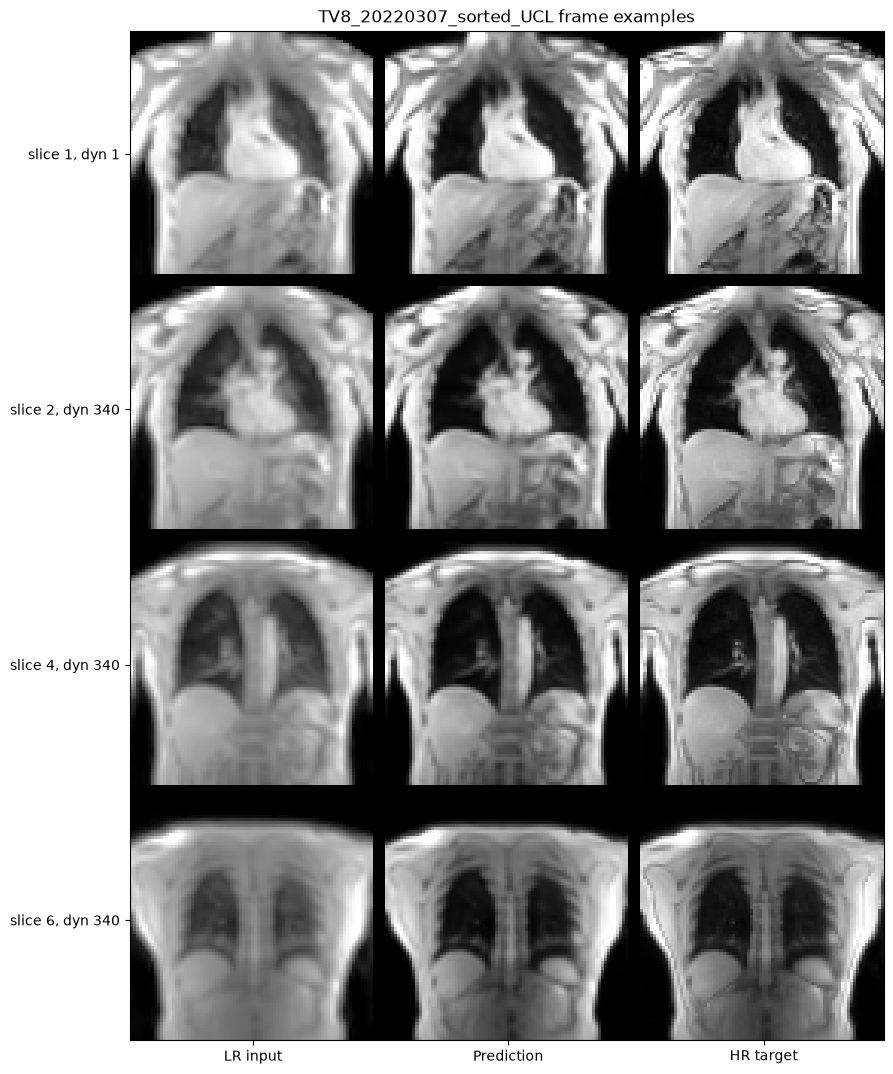

In [17]:
if evaluation_checkpoint.exists():
    frame_positions = np.linspace(0, len(test_idx) - 1, min(4, len(test_idx)), dtype=int)
    spacer = np.zeros((CROP_SIZE, 4), dtype=np.float32)
    rows = []

    for pos in frame_positions:
        rows.append(np.concatenate([lr_images[pos], spacer, pred_images[pos], spacer, hr_images[pos]], axis=1))

    row_spacer = np.zeros((4, rows[0].shape[1]), dtype=np.float32)
    grid_parts = []
    for i, row in enumerate(rows):
        if i:
            grid_parts.append(row_spacer)
        grid_parts.append(row)
    frame_grid = np.concatenate(grid_parts, axis=0)

    column_width = CROP_SIZE + 4
    x_ticks = [CROP_SIZE / 2, column_width + CROP_SIZE / 2, 2 * column_width + CROP_SIZE / 2]
    y_ticks = [i * (CROP_SIZE + 4) + CROP_SIZE / 2 for i in range(len(frame_positions))]
    y_labels = [f"slice {sl[test_idx[pos]]}, dyn {dyn[test_idx[pos]]}" for pos in frame_positions]

    plt.figure(figsize=(9, 3 * len(frame_positions)))
    plt.imshow(frame_grid, cmap="gray", vmin=0, vmax=1)
    plt.xticks(x_ticks, ["LR input", "Prediction", "HR target"])
    plt.yticks(y_ticks, y_labels)
    plt.title(f"{TEST_SUBJECT} frame examples")
    plt.tight_layout()
    plt.show()


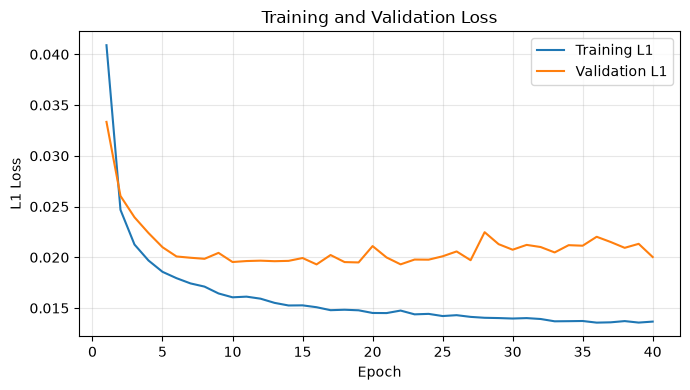

In [19]:
history_df = pd.DataFrame(history)

plt.figure(figsize=(7, 4))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training L1"
)

plt.plot(
    history_df["epoch"],
    history_df["loss"],
    label="Validation L1"
)

plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()